# Extra figures

Supplementary plots not included in the main section notebooks.

In [21]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent / 'src'))

import glob

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [22]:
repo_root   = Path().resolve().parents[1]
voronoi_dir = repo_root / 'data' / 'voronois'
p_field_dir = repo_root / 'data' / 'probability_fields'

cmap       = 'RdYlBu_r'
n_demes    = 4000
start_year = 1950

gdf_voronoi = gpd.read_file(voronoi_dir / f'Voronoi_{n_demes}_raw_kmeans_demes.gpkg')
print(f'CRS: {gdf_voronoi.crs}  (units: metres)')
print(f'Full extent  x: {gdf_voronoi.total_bounds[0]:.0f} – {gdf_voronoi.total_bounds[2]:.0f}')
print(f'             y: {gdf_voronoi.total_bounds[1]:.0f} – {gdf_voronoi.total_bounds[3]:.0f}')

fig_dir = repo_root / 'figures'
fig_dir.mkdir(exist_ok=True)


CRS: EPSG:32615  (units: metres)
Full extent  x: -2185110 – 2557900
             y: 2822864 – 5869283


## §1: Tennis / sneakers state field — northeast USA, 1950

In [23]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────
plot_year   = 1950
variant_idx = 1      # 0 = 'tennis', 1 = 'sneakers'

# Zoom region in the GDF's native CRS (EPSG:32615, metres).
# Run the paths cell first — it prints the full USA extent for reference.
# Approximate northeast defaults; adjust to taste.
xlim = (1_000_000, 2_600_000)   # roughly Pittsburgh → Maine coast
ylim = (4_000_000, 5_600_000)   # roughly DC latitude → northern Maine
# ─────────────────────────────────────────────────────────────────────────────

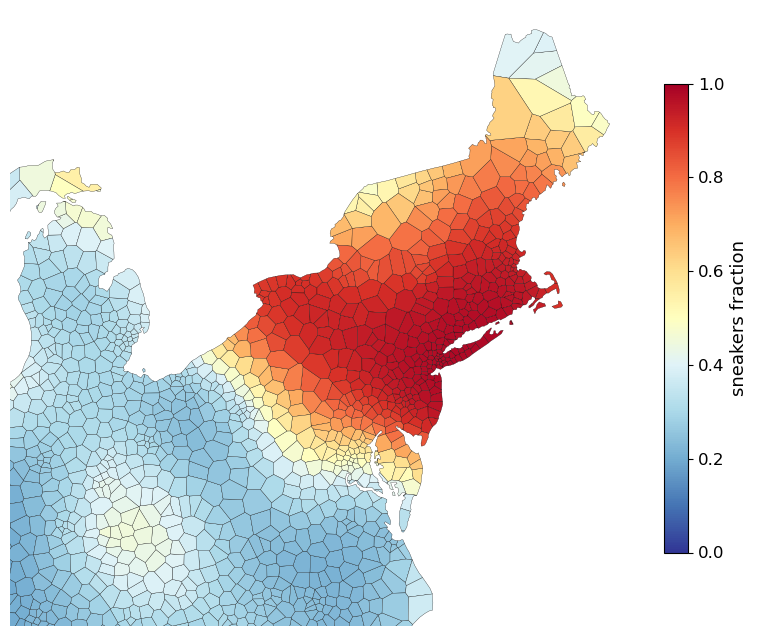

In [24]:
tennis_files = glob.glob(str(p_field_dir / 'v_4_tennis_sneakers_*.npy'))
assert tennis_files, 'No tennis_sneakers v_4 field found in data/probability_fields/'
P = np.load(tennis_files[0])   # (N, T, K)
variant_names = ['tennis', 'sneakers']

t = plot_year - start_year
data = P[:, t, variant_idx]

fig, ax = plt.subplots(figsize=(8, 7))
gdf_voronoi.plot(
    column=data, ax=ax,
    cmap=cmap, vmin=0, vmax=1,
    linewidth=0.2, edgecolor='k'
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_axis_off()
#ax.set_title(f'{variant_names[variant_idx]} — {plot_year}', fontsize=13)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
#fig.colorbar(sm, ax=ax, shrink=0.6, label=f'P({variant_names[variant_idx]})')
cbar = fig.colorbar(sm, ax=ax, shrink=0.7, label=f'{variant_names[variant_idx]} fraction')
cbar.set_label(f'{variant_names[variant_idx]} fraction', fontsize=13)
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
fig.savefig(fig_dir / f'{variant_names[variant_idx]}_{plot_year}_northeast.png', dpi=300, bbox_inches='tight')
plt.show()